# Lab Exercise: Imitation Learning using Behavioral Cloning

## Objective
Train an agent to imitate an expert's behavior using supervised learning.

By the end of this lab, students will:
- Generate expert demonstration data
- Prepare a dataset
- Train a behavioral cloning model
- Test and visualize the learned behavior


## Problem Setup

We use a very simple 1D environment:
- The agent is on a number line
- The target is placed at a random position
- The agent can move:
  - `-1` = move left
  - `+1` = move right

### Expert Rule
The expert always moves toward the target:

```python
if agent_pos < target:
    action = 1
else:
    action = -1
```

The model will learn to copy this expert behavior.


## Step 0: Install Required Libraries

Run this only if the libraries are not already installed.


In [4]:
# Uncomment and run if needed
!uv pip  install numpy matplotlib scikit-learn


Resolved 15 packages in 1.34s
 Downloaded fonttools
 Downloaded pillow
 Downloaded matplotlib
 Downloaded scikit-learn
 Downloaded scipy
Prepared 11 packages in 9.46s
         If the cache and target directories are on different filesystems, hardlinking may not be supported.
         If this is intentional, set `export UV_LINK_MODE=copy` or use `--link-mode=copy` to suppress this warning.
Installed 12 packages in 11.79s
 + contourpy==1.3.3
 + cycler==0.12.1
 + fonttools==4.62.1
 + joblib==1.5.3
 + kiwisolver==1.5.0
 + matplotlib==3.10.9
 + numpy==2.4.4
 + pillow==12.2.0
 + pyparsing==3.3.2
 + scikit-learn==1.8.0
 + scipy==1.17.1
 + threadpoolctl==3.6.0


## Step 1: Import Libraries

We will use:
- `numpy` for data generation
- `matplotlib` for visualization
- `LogisticRegression` from scikit-learn for behavioral cloning


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


## Step 2: Generate Expert Demonstration Data

We create a dataset of `(agent_position, target_position, action)`.

### Student Task
Observe how the expert makes the correct decision for each state.


In [8]:
data = []

for _ in range(1000):
    agent_pos = np.random.randint(-10, 10)
    target = np.random.randint(-10, 10)

    if agent_pos < target:
        action = 1
    else:
        action = -1

    data.append([agent_pos, target, action])

data = np.array(data)
print('Dataset shape:', data.shape)
print('First 10 samples:')
print(data[:20])


Dataset shape: (1000, 3)
First 10 samples:
[[  2   9   1]
 [ -9   5   1]
 [  1   9   1]
 [  9 -10  -1]
 [  9   8  -1]
 [  6  -2  -1]
 [  4   4  -1]
 [ -4   0   1]
 [ -4  -4  -1]
 [  2   3   1]
 [ -9   0   1]
 [  1  -6  -1]
 [  3   3  -1]
 [ -7   6   1]
 [  3  -7  -1]
 [  2  -7  -1]
 [  1  -3  -1]
 [ -7  -6   1]
 [  1   3   1]
 [  8  -1  -1]]


## Step 3: Prepare the Dataset

- Input `X` will contain the state: `[agent_pos, target]`
- Output `y` will contain the action: `-1` or `+1`


In [9]:
X = data[:, :2]
y = data[:, 2]

print('Input shape:', X.shape)
print('Output shape:', y.shape)
print('Unique actions:', np.unique(y))


Input shape: (1000, 2)
Output shape: (1000,)
Unique actions: [-1  1]


## Step 4: Split into Training and Testing Data

We keep some data aside to test whether the model learned correctly.


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Training samples:', len(X_train))
print('Testing samples:', len(X_test))


Training samples: 800
Testing samples: 200


## Step 5: Train the Behavioral Cloning Model

We use logistic regression as a simple classifier.

The model learns:

**State** → **Action**


In [11]:
model = LogisticRegression()
model.fit(X_train, y_train)

print('Model training complete.')


Model training complete.


## Step 6: Evaluate the Model

Now we check how accurately the learned model copies the expert.


In [12]:
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print('Test Accuracy:', acc)
print('\nClassification Report:')
print(classification_report(y_test, y_pred))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))


Test Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

          -1       1.00      1.00      1.00       103
           1       1.00      1.00      1.00        97

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

Confusion Matrix:
[[103   0]
 [  0  97]]


## Step 7: Test the Agent in a Small Simulation

We now let the trained model control the agent.

Example:
- Start position = `0`
- Target position = `7`

At every step, the model predicts whether to move left or right.


In [13]:
agent_pos = 0
target = 7

print(f'Start position: {agent_pos}, Target: {target}')

for step in range(10):
    state = np.array([[agent_pos, target]])
    action = model.predict(state)[0]
    agent_pos += action
    print(f'Step {step+1}: action={action}, new_position={agent_pos}')
    
    if agent_pos == target:
        print('Target reached!')
        break


Start position: 0, Target: 7
Step 1: action=1, new_position=1
Step 2: action=1, new_position=2
Step 3: action=1, new_position=3
Step 4: action=1, new_position=4
Step 5: action=1, new_position=5
Step 6: action=1, new_position=6
Step 7: action=1, new_position=7
Target reached!


## Step 8: Visualize the Agent's Movement

This graph shows how the agent moves over time toward the target.


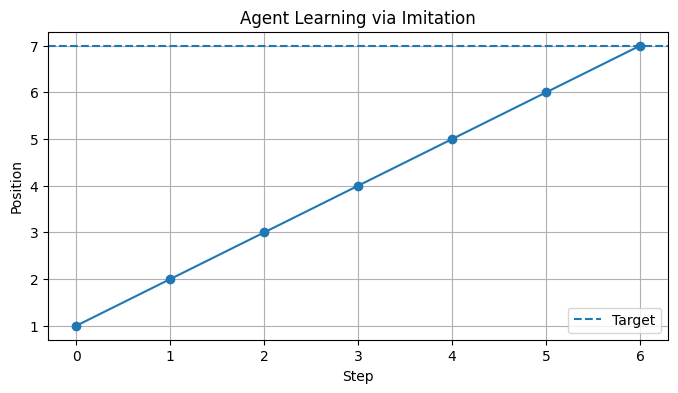

In [14]:
positions = []
agent_pos = 0
target = 7

for _ in range(10):
    state = np.array([[agent_pos, target]])
    action = model.predict(state)[0]
    agent_pos += action
    positions.append(agent_pos)
    if agent_pos == target:
        break

plt.figure(figsize=(8, 4))
plt.plot(positions, marker='o')
plt.axhline(target, linestyle='--', label='Target')
plt.title('Agent Learning via Imitation')
plt.xlabel('Step')
plt.ylabel('Position')
plt.legend()
plt.grid(True)
plt.show()


## Step 9: Try Different Start and Target Positions

Students can change these values and observe the agent's behavior.


Start position: -5, Target: 3
Step 1: action=1, new_position=-4
Step 2: action=1, new_position=-3
Step 3: action=1, new_position=-2
Step 4: action=1, new_position=-1
Step 5: action=1, new_position=0
Step 6: action=1, new_position=1
Step 7: action=1, new_position=2
Step 8: action=1, new_position=3
Target reached!


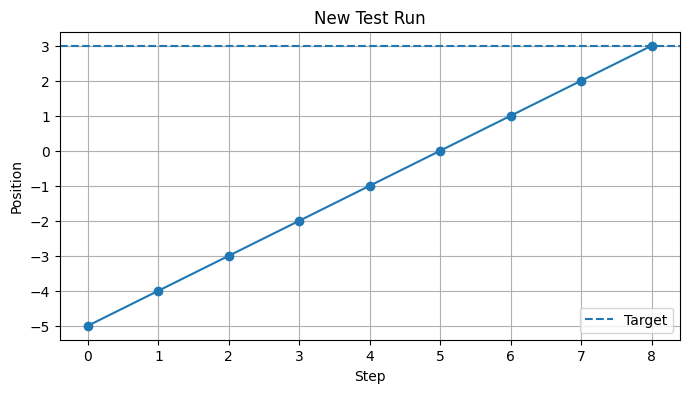

In [15]:
agent_pos = -5
target = 3

positions = [agent_pos]
print(f'Start position: {agent_pos}, Target: {target}')

for step in range(15):
    state = np.array([[agent_pos, target]])
    action = model.predict(state)[0]
    agent_pos += action
    positions.append(agent_pos)
    print(f'Step {step+1}: action={action}, new_position={agent_pos}')
    
    if agent_pos == target:
        print('Target reached!')
        break

plt.figure(figsize=(8, 4))
plt.plot(positions, marker='o')
plt.axhline(target, linestyle='--', label='Target')
plt.title('New Test Run')
plt.xlabel('Step')
plt.ylabel('Position')
plt.legend()
plt.grid(True)
plt.show()


## Step 10: Distribution Shift Experiment

Behavioral cloning can fail when the model sees states very different from training data.

Our training data mostly used values between `-10` and `10`.
Now test the model outside that range.


Start position: 50, Target: -20
Step 1: action=-1, new_position=49
Step 2: action=-1, new_position=48
Step 3: action=-1, new_position=47
Step 4: action=-1, new_position=46
Step 5: action=-1, new_position=45
Step 6: action=-1, new_position=44
Step 7: action=-1, new_position=43
Step 8: action=-1, new_position=42
Step 9: action=-1, new_position=41
Step 10: action=-1, new_position=40
Step 11: action=-1, new_position=39
Step 12: action=-1, new_position=38
Step 13: action=-1, new_position=37
Step 14: action=-1, new_position=36
Step 15: action=-1, new_position=35
Step 16: action=-1, new_position=34
Step 17: action=-1, new_position=33
Step 18: action=-1, new_position=32
Step 19: action=-1, new_position=31
Step 20: action=-1, new_position=30


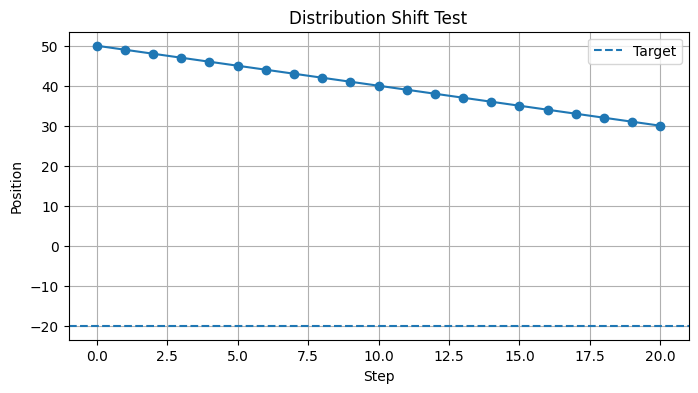

In [16]:
agent_pos = 50
target = -20

positions = [agent_pos]
print(f'Start position: {agent_pos}, Target: {target}')

for step in range(20):
    state = np.array([[agent_pos, target]])
    action = model.predict(state)[0]
    agent_pos += action
    positions.append(agent_pos)
    print(f'Step {step+1}: action={action}, new_position={agent_pos}')
    
    if agent_pos == target:
        print('Target reached!')
        break

plt.figure(figsize=(8, 4))
plt.plot(positions, marker='o')
plt.axhline(target, linestyle='--', label='Target')
plt.title('Distribution Shift Test')
plt.xlabel('Step')
plt.ylabel('Position')
plt.legend()
plt.grid(True)
plt.show()


## Step 11: Reflection Questions

Students should answer these questions in their lab report:

1. What is imitation learning?
2. What is behavioral cloning?
3. What are the inputs and outputs in this lab?
4. Did the agent successfully imitate the expert?
5. What is distribution shift?
6. Why can imitation learning fail in unseen situations?
7. How could we improve this model?


## Bonus Task

Try one or more of these:
- Increase dataset size from `1000` to `5000`
- Add random noise to the agent position
- Replace logistic regression with a neural network
- Collect more difficult examples and retrain the model


## Instructor Note

This lab demonstrates the simplest form of imitation learning.

Important idea:
- No reward is used
- The model simply learns to copy expert decisions

So this is **Behavioral Cloning**, which is a supervised learning approach to imitation learning.
